This is UNET with dual attention module(only at bottleneck) with dropouts(all same 10%). This model is trained with custom error function made up of categorical cross entropy function, jaccard loss funciton, tversky loss funciton and boundary loss function.(10:3:3:2)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import cv2
import PIL.Image as Image
from PIL import ImageOps
import os
import glob as glob
import seaborn as sns

import tensorflow as tf
from keras import layers, models, callbacks
from keras.models import Sequential, Model
from keras.utils import load_img, normalize
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Conv2DTranspose, AveragePooling2D, Add
from keras.layers import Concatenate, concatenate, BatchNormalization, Dropout, Lambda, Activation
from keras.applications import ResNet50

from tqdm import tqdm
from skimage.io import imread, imshow
from skimage.transform import resize
import random
from IPython.display import Image, display

from sklearn.metrics import confusion_matrix
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score, jaccard_score, confusion_matrix
)
from sklearn.metrics import precision_recall_fscore_support

from keras.models import Model
from keras import backend as K

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import secrets

SEED = secrets.randbits(32)
print("Seed used:", SEED)

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

Seed used: 2786664403


Save Paths

In [4]:
filename = "LinkNet_P1"
foldername = "finalsaves/LinkNet/l1/"
pathsave = "/content/drive/MyDrive/"
save_dir = os.path.join(pathsave, foldername)
os.makedirs(save_dir, exist_ok=True)
modelsave = pathsave + foldername + filename + ".h5"
modelweightsave = pathsave + foldername + filename + "_w.weights.h5"
modelmetricscsv = pathsave + foldername + filename + "_metrics.csv"
modelhistory = pathsave + foldername + filename + "_Train_history.csv"
confusionmatrix = pathsave + foldername + filename + "_cnfm.png"
confusionmatrixcsv = pathsave + foldername + filename + "_cnfcs.csv"
regmetrics = pathsave + foldername + filename + "_reg_metrics.csv"

In [5]:
print(modelsave)
print(modelweightsave)
print(modelmetricscsv)
print(modelhistory)
print(confusionmatrix)
print(confusionmatrixcsv)
print(regmetrics)

/content/drive/MyDrive/finalsaves/LinkNet/l1/LinkNet_P1.h5
/content/drive/MyDrive/finalsaves/LinkNet/l1/LinkNet_P1_w.weights.h5
/content/drive/MyDrive/finalsaves/LinkNet/l1/LinkNet_P1_metrics.csv
/content/drive/MyDrive/finalsaves/LinkNet/l1/LinkNet_P1_Train_history.csv
/content/drive/MyDrive/finalsaves/LinkNet/l1/LinkNet_P1_cnfm.png
/content/drive/MyDrive/finalsaves/LinkNet/l1/LinkNet_P1_cnfcs.csv
/content/drive/MyDrive/finalsaves/LinkNet/l1/LinkNet_P1_reg_metrics.csv


In [6]:
IMG_HEIGHT = 256
IMG_WIDTH = 256
IMG_CLASSES = 5
IMG_CHANNELS = 3

IMG_PATH = '/content/drive/MyDrive/dataset/ng/train/images'
LABELS_PATH = '/content/drive/MyDrive/dataset/ng/train/masks'


IMG_PATH_TEST = '/content/drive/MyDrive/dataset/ng/test/images'
LABELS_PATH_TEST = '/content/drive/MyDrive/dataset/ng/test/masks'

In [7]:
import os

try:
    IMG_IDS = sorted(os.listdir(IMG_PATH))
    LABELS_IDS = sorted(os.listdir(LABELS_PATH))
    IMG_IDS_TEST = sorted(os.listdir(IMG_PATH_TEST))
    LABELS_IDS_TEST = sorted(os.listdir(LABELS_PATH_TEST))
except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Please check that the directory exists.")

In [8]:
COLOR_MAP = [
    [0, 0, 0],
    [0, 255, 255],
    [255, 0, 0],
    [153, 76, 0],
    [0, 153, 0],
]

def process_mask(rgb_mask, colormap):
    output_mask = []

    for i, color in enumerate(colormap):
        cmap = np.all(np.equal(rgb_mask, color), axis=-1)
        output_mask.append(cmap)

    output_mask = np.stack(output_mask, axis=-1)
    return output_mask

In [9]:
train_images = []
train_masks = []

test_images = []
test_masks = []

In [10]:
for image_filename, mask_filename in tqdm(zip(IMG_IDS, LABELS_IDS),total = len(IMG_IDS)):
    image_path = os.path.join(IMG_PATH, image_filename)
    mask_path = os.path.join(LABELS_PATH, mask_filename)

    image = cv2.imread(image_path,cv2.IMREAD_COLOR)

    image = cv2.resize(image, (IMG_HEIGHT, IMG_WIDTH))

    # normalizing the image
    image = image / 255.0

    mask = cv2.imread(mask_path, cv2.IMREAD_COLOR)
    mask = cv2.resize(mask, (IMG_HEIGHT, IMG_WIDTH))
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

    processed_mask = process_mask(mask,COLOR_MAP)
    grayscale_mask = np.argmax(processed_mask, axis=-1)
    grayscale_mask = np.expand_dims(grayscale_mask, axis=-1)

    train_images.append(image)
    train_masks.append(grayscale_mask)

# Convert the lists to arrays
train_images = np.array(train_images)
train_masks = np.array(train_masks)

100%|██████████| 1002/1002 [00:46<00:00, 21.42it/s]


In [11]:
train_masks.shape
unique_values = np.unique(train_masks)
print("Unique values in train_masks:", unique_values)

Unique values in train_masks: [0 1 2 3 4]


In [12]:
for image_filename, mask_filename in tqdm(zip(IMG_IDS_TEST, LABELS_IDS_TEST),total = len(IMG_IDS_TEST)):
    image_path = os.path.join(IMG_PATH_TEST, image_filename)
    mask_path = os.path.join(LABELS_PATH_TEST, mask_filename)

    image = cv2.imread(image_path,cv2.IMREAD_COLOR)

    image = cv2.resize(image, (IMG_HEIGHT, IMG_WIDTH))

    # normalizing the image
    image = image / 255.0

    mask = cv2.imread(mask_path, cv2.IMREAD_COLOR)
    mask = cv2.resize(mask, (IMG_HEIGHT, IMG_WIDTH))
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

    processed_mask = process_mask(mask,COLOR_MAP)
    grayscale_mask = np.argmax(processed_mask, axis=-1)
    grayscale_mask = np.expand_dims(grayscale_mask, axis=-1)

    test_images.append(image)
    test_masks.append(grayscale_mask)

# Convert the lists to np arrays
test_images = np.array(test_images)
test_masks = np.array(test_masks)


100%|██████████| 110/110 [00:05<00:00, 21.33it/s]


In [13]:
test_masks.shape
unique_values = np.unique(test_masks)
print("Unique values in test_masks:", unique_values)

Unique values in test_masks: [0 1 2 3 4]


In [14]:
from keras.utils import to_categorical

train_masks = to_categorical(train_masks, num_classes = 5)

In [15]:
#one last check
print("train_image_shape",train_images.shape)
print("train_masks_shape",train_masks.shape)
print("test_image_shape",test_images.shape)
print("test_masks_shape",test_masks.shape)
print("train_mask_unique",np.unique(train_masks))
print("test_mask_unique",np.unique(test_masks))

train_image_shape (1002, 256, 256, 3)
train_masks_shape (1002, 256, 256, 5)
test_image_shape (110, 256, 256, 3)
test_masks_shape (110, 256, 256, 1)
train_mask_unique [0. 1.]
test_mask_unique [0 1 2 3 4]


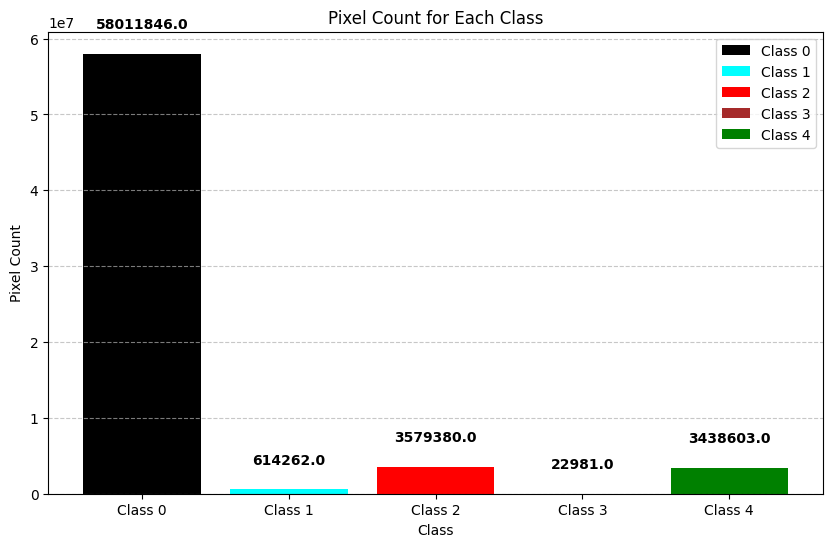

In [16]:
#pixel counts
num_classes = 5
class_pixel_counts = np.sum(train_masks, axis=(0, 1, 2))
class_labels = [f'Class {i}' for i in range(num_classes)]
colors = ['black', 'cyan', 'red', 'brown', 'green']
plt.figure(figsize=(10, 6))
bars = plt.bar(class_labels, class_pixel_counts, color=colors)
plt.xlabel('Class')
plt.ylabel('Pixel Count')
plt.title('Pixel Count for Each Class')
plt.legend(bars, class_labels)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar, count in zip(bars, class_pixel_counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05 * max(class_pixel_counts),
             f'{count}', ha='center', va='bottom', color='black', fontweight='bold')

plt.show()


Model architecture Starts here

In [17]:
input_shape = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

In [18]:
def conv_block(x, filters):
    x = Conv2D(filters, (3,3), padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, (3,3), padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x
def LinkNet(input_shape, num_classes):
    inputs = Input(input_shape)

    # -------- Encoder --------
    e1 = conv_block(inputs, 64)
    p1 = MaxPooling2D((2,2))(e1)

    e2 = conv_block(p1, 128)
    p2 = MaxPooling2D((2,2))(e2)

    e3 = conv_block(p2, 256)
    p3 = MaxPooling2D((2,2))(e3)

    e4 = conv_block(p3, 512)

    # -------- Decoder --------
    d3 = UpSampling2D((2,2))(e4)
    d3 = Conv2D(256, (3,3), padding='same')(d3)
    d3 = Add()([d3, e3])
    d3 = Activation('relu')(d3)

    d2 = UpSampling2D((2,2))(d3)
    d2 = Conv2D(128, (3,3), padding='same')(d2)
    d2 = Add()([d2, e2])
    d2 = Activation('relu')(d2)

    d1 = UpSampling2D((2,2))(d2)
    d1 = Conv2D(64, (3,3), padding='same')(d1)
    d1 = Add()([d1, e1])
    d1 = Activation('relu')(d1)

    # -------- Output --------
    outputs = Conv2D(num_classes, (1,1), activation='softmax')(d1)

    model = Model(inputs, outputs, name="LinkNet")
    return model


In [19]:
LinkNet_model = LinkNet(input_shape, IMG_CLASSES)

LinkNet_model.summary()

Model: "LinkNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 6,242,117 (23.81 MB)

 Trainable params: 6,238,277 (23.80 MB)

 Non-trainable params: 3,840 (15.00 KB)

Custom boundary Loss function

Pre-Training Process

In [20]:
tf.keras.backend.clear_session()

In [21]:
LinkNet_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
checkpoint = ModelCheckpoint("best_LinkNet_model.keras",monitor="val_loss",mode="min",save_best_only=True,verbose=1)

Training

In [23]:
#LinkNet_model.compile()
LinkNet_history = LinkNet_model.fit(train_images, train_masks,
                    epochs=100,
                    batch_size=16,
                    validation_split=0.1,
                    verbose=1,
                    callbacks=[checkpoint])

Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 973ms/step - accuracy: 0.8198 - loss: 0.8932
Epoch 1: val_loss improved from inf to 2.13517, saving model to best_LinkNet_model.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.8206 - loss: 0.8882 - val_accuracy: 0.1986 - val_loss: 2.1352
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.9021 - loss: 0.2912
Epoch 2: val_loss improved from 2.13517 to 0.86962, saving model to best_LinkNet_model.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 43s 755ms/step - accuracy: 0.9019 - loss: 0.2914 - val_accuracy: 0.6320 - val_loss: 0.8696
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.9088 - loss: 0.2744
Epoch 3: val_loss improved from 0.86962 to 0.27277, saving model to best_LinkNet_model.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 39s 687ms/step - accuracy: 0.9086 - loss: 0.2746 - val_accuracy: 0.9279 - val_loss: 0.2728
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.9126 - loss: 0.2573
Epoch 4: val_loss did not

In [24]:
LinkNet_model.save(modelsave)
LinkNet_model.save_weights(modelweightsave)

Analysis:

Training Accuracy and Loss

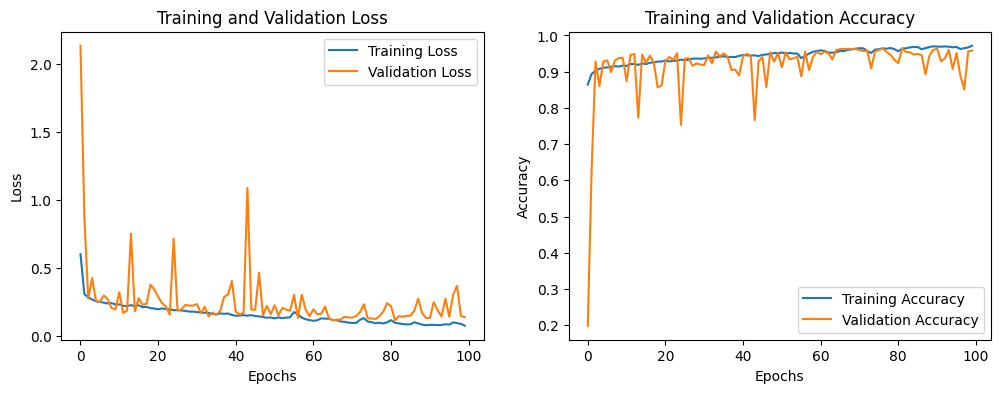

In [25]:
# Access the training history
LinkNet_loss = LinkNet_history.history['loss']
LinkNet_val_loss = LinkNet_history.history['val_loss']
LinkNet_accuracy = LinkNet_history.history['accuracy']
LinkNet_val_accuracy = LinkNet_history.history['val_accuracy']

# Plot training and validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(LinkNet_loss, label='Training Loss')
plt.plot(LinkNet_val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(LinkNet_accuracy, label='Training Accuracy')
plt.plot(LinkNet_val_accuracy, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

history_df = pd.DataFrame(LinkNet_history.history)
history_df.to_csv(modelhistory, index=False)

Testing:

In [26]:
prediction_LinkNet = LinkNet_model.predict(test_images)

print(test_masks.shape)
print(prediction_LinkNet.shape)

4/4 ━━━━━━━━━━━━━━━━━━━━ 52s 6s/step
(110, 256, 256, 1)
(110, 256, 256, 5)


In [27]:
# Convert prediction to class labels (no post-processing)
pred_masks = np.argmax(prediction_LinkNet, axis=-1)

# Directly use predicted masks
processed_pred_masks = pred_masks

# Flatten for metrics
LinkNet_true_labels = test_masks.flatten()
LinkNet_predicted_labels = processed_pred_masks.flatten()

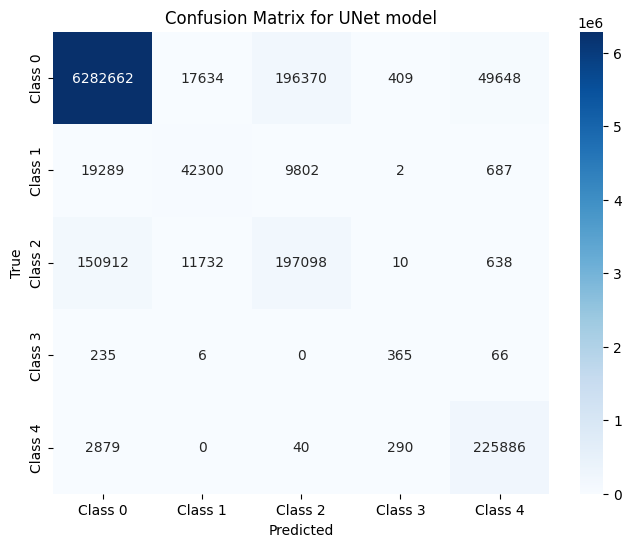

In [28]:
# Create the confusion matrix
cm = confusion_matrix(LinkNet_true_labels, LinkNet_predicted_labels)

# Save confusion matrix as CSV
pd.DataFrame(cm,
             index=['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4'],
             columns=['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4']
            ).to_csv(confusionmatrixcsv, index=True)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4'],
            yticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for UNet model')

# Save plot as PNG
plt.savefig(confusionmatrix, bbox_inches='tight')
plt.show()

In [ ]:
from matplotlib.colors import ListedColormap

i = 25  # Index of a test image (try a few)
image = test_images[i]
true_mask = test_masks[i]

# Create a custom colormap from the COLOR_MAP list
n_classes = len(COLOR_MAP)
normalized_colors = np.array(COLOR_MAP) / 255.0
cmap = ListedColormap(normalized_colors)

test_image_number = random.randint(0, len(test_images) - 1)

num_images_to_plot = 110
for i in range(num_images_to_plot):
    plt.figure(figsize=(12, 6))  # Adjust the figure size as needed

    # Test Image
    plt.subplot(1, 3, 1)  # Subplot for the image
    test_image = test_images[i]
    plt.imshow(test_image)  # Display the image
    plt.title("Image")

    # Test Mask
    plt.subplot(1, 3, 2)  # Subplot for the test mask
    test_mask = test_masks[i]
    plt.imshow(test_mask.squeeze(), cmap=cmap, vmin=0, vmax=len(COLOR_MAP) - 1, interpolation='none')
    plt.colorbar(ticks=range(len(COLOR_MAP)))
    plt.title("Test Mask")

    # Predicted Mask
    plt.subplot(1, 3, 3)  # Subplot for the predicted mask
    prediction_LinkNet = LinkNet_model.predict(np.expand_dims(test_image, axis=0))
    predicted_mask_LinkNet = np.argmax(prediction_LinkNet, axis=3)[0, :, :]
    plt.imshow(predicted_mask_LinkNet.squeeze(), cmap=cmap, vmin=0, vmax=len(COLOR_MAP) - 1, interpolation='none')
    plt.colorbar(ticks=range(len(COLOR_MAP)))
    plt.title("Predicted Mask")

    plt.show()

Metrics

In [ ]:
# Dice coefficient
def dice_score(y_true, y_pred, cls):
    y_true_c = (y_true == cls).astype(np.int32)
    y_pred_c = (y_pred == cls).astype(np.int32)
    intersection = np.sum(y_true_c * y_pred_c)
    return (2.0 * intersection) / (np.sum(y_true_c) + np.sum(y_pred_c) + 1e-7)

# Per-class accuracy
def per_class_accuracy(y_true, y_pred, cls):
    y_true_c = (y_true == cls).astype(np.int32)
    y_pred_c = (y_pred == cls).astype(np.int32)
    TP = np.sum((y_true_c == 1) & (y_pred_c == 1))
    TN = np.sum((y_true_c == 0) & (y_pred_c == 0))
    FP = np.sum((y_true_c == 0) & (y_pred_c == 1))
    FN = np.sum((y_true_c == 1) & (y_pred_c == 0))
    return (TP + TN) / (TP + TN + FP + FN + 1e-7)

# Initialize table
results = []

classes = np.unique(LinkNet_true_labels)

# Per-class metrics
for cls in classes:
    cls_precision = precision_score(LinkNet_true_labels, LinkNet_predicted_labels, average=None, labels=[cls], zero_division=0)[0]
    cls_recall = recall_score(LinkNet_true_labels, LinkNet_predicted_labels, average=None, labels=[cls], zero_division=0)[0]
    cls_f1 = f1_score(LinkNet_true_labels, LinkNet_predicted_labels, average=None, labels=[cls], zero_division=0)[0]
    cls_iou = jaccard_score(LinkNet_true_labels, LinkNet_predicted_labels, average=None, labels=[cls], zero_division=0)[0]
    cls_dice = dice_score(LinkNet_true_labels, LinkNet_predicted_labels, cls)
    cls_accuracy = per_class_accuracy(LinkNet_true_labels, LinkNet_predicted_labels, cls)

    results.append({
        "Class": cls,
        "Precision": cls_precision,
        "Recall": cls_recall,
        "F1": cls_f1,
        "IoU": cls_iou,
        "Dice": cls_dice,
        "Accuracy": cls_accuracy
    })

# Macro average (equal weight for all classes)
macro_precision = precision_score(LinkNet_true_labels, LinkNet_predicted_labels, average="macro", zero_division=0)
macro_recall = recall_score(LinkNet_true_labels, LinkNet_predicted_labels, average="macro", zero_division=0)
macro_f1 = f1_score(LinkNet_true_labels, LinkNet_predicted_labels, average="macro", zero_division=0)
macro_iou = jaccard_score(LinkNet_true_labels, LinkNet_predicted_labels, average="macro", zero_division=0)
macro_dice = np.mean([dice_score(LinkNet_true_labels, LinkNet_predicted_labels, cls) for cls in classes])
macro_accuracy = np.mean([per_class_accuracy(LinkNet_true_labels, LinkNet_predicted_labels, cls) for cls in classes])

results.append({
    "Class": "Macro Avg",
    "Precision": macro_precision,
    "Recall": macro_recall,
    "F1": macro_f1,
    "IoU": macro_iou,
    "Dice": macro_dice,
    "Accuracy": macro_accuracy
})

# Weighted / overall metrics
weighted_precision = precision_score(LinkNet_true_labels, LinkNet_predicted_labels, average="weighted", zero_division=0)
weighted_recall = recall_score(LinkNet_true_labels, LinkNet_predicted_labels, average="weighted", zero_division=0)
weighted_f1 = f1_score(LinkNet_true_labels, LinkNet_predicted_labels, average="weighted", zero_division=0)
weighted_iou = jaccard_score(LinkNet_true_labels, LinkNet_predicted_labels, average="weighted", zero_division=0)
weighted_dice = np.sum([dice_score(LinkNet_true_labels, LinkNet_predicted_labels, cls) *
                        np.sum(LinkNet_true_labels == cls) for cls in classes]) / len(LinkNet_true_labels)
weighted_accuracy = accuracy_score(LinkNet_true_labels, LinkNet_predicted_labels)

results.append({
    "Class": "Weighted / Overall",
    "Precision": weighted_precision,
    "Recall": weighted_recall,
    "F1": weighted_f1,
    "IoU": weighted_iou,
    "Dice": weighted_dice,
    "Accuracy": weighted_accuracy
})

# Create DataFrame with fixed column order
df = pd.DataFrame(results)
cols = ["Class", "Precision", "Recall", "F1", "IoU", "Dice", "Accuracy"]
df = df[cols]

# Save to CSV
df.to_csv(modelmetricscsv, index=False)

# Print neatly
print("Saved metrics to atun_metrics.csv")
print(df.to_string(index=False, float_format="%.6f"))


Saved metrics to atun_metrics.csv
             Class  Precision   Recall       F1      IoU     Dice  Accuracy
                 0   0.973154 0.959665 0.966363 0.934915 0.966363  0.939329
                 1   0.590189 0.586848 0.588514 0.416946 0.588514  0.991795
                 2   0.488701 0.546902 0.516166 0.347860 0.516166  0.948744
                 3   0.339219 0.543155 0.417620 0.263919 0.417620  0.999859
                 4   0.815694 0.985993 0.892795 0.806350 0.892795  0.992475
         Macro Avg   0.641391 0.724513 0.676291 0.553998 0.676291  0.974440
Weighted / Overall   0.940043 0.936100 0.937689 0.896239 0.937689  0.936100


Regression Matrix

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math

# --- Flatten masks (already done above) ---
y_true = LinkNet_true_labels
y_pred = LinkNet_predicted_labels

# --- Regression Metrics ---
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = math.sqrt(mse)
r2 = r2_score(y_true, y_pred)

# MAPE (Mean Absolute Percentage Error) - avoid division by zero
mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-7))) * 100

# MSLE (Mean Squared Logarithmic Error) - works only if values >= 0
msle = mean_squared_error(np.log1p(y_true), np.log1p(y_pred))

# --- Save all metrics to CSV ---
regression_results = {
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2,
    "MAPE": mape,
    "MSLE": msle
}

df_regression = pd.DataFrame([regression_results])
df_regression.to_csv(regmetrics, index=False)

print("Regression metrics saved to lapLinkNet_regression_metrics.csv")
print(df_regression.to_string(index=False, float_format="%.6f"))

Regression metrics saved to lapLinkNet_regression_metrics.csv
     MAE      MSE     RMSE       R2            MAPE     MSLE
0.134397 0.319478 0.565224 0.518077 84643696.064474 0.080248
